In [2]:
import numpy as np
import matplotlib.pyplot as plt


Text(0, 0.5, 'solution in time')

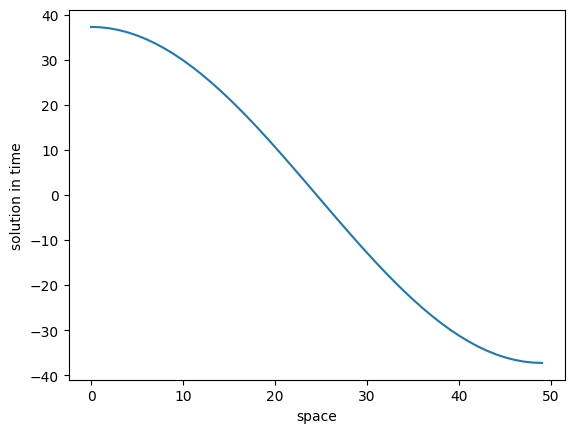

In [ ]:
# SOLUZIONE ESATTA

exact_solution = lambda x, t: 100 * np.exp(-np.pi**2 * t) * np.cos(np.pi * x)
L, T = 1, 0.1
n, m= 50, 1000
alpha = 1
x = np.linspace(0, L, n)  
t = np.linspace(0, T, m) 

for j in range(m-1):
    u_exact = exact_solution(x, t[j+1])

plt.plot(u_exact)
plt.xlabel("space")
plt.ylabel("solution in time")

In [37]:

# DISCRETIZZAZIONE EQ CALORE - 1D SPAZIO TEMPO
# neuman =  non c'è flusso ai bordo 


# Funzione per calcolare l'errore massimo
def solve_heat_equation(n, m):
    h = L / (n-1)
    tau = T / m  

    # Griglia
    x = np.linspace(0, L, n)  
    t = np.linspace(0, T, m) 
    r =  tau / h**2  # alpha coeff diffusione

## MATRICE impx 
    A = (1 + r) * np.eye(n) - r/2* np.diag(np.ones(n - 1), 1) - r/2* np.diag(np.ones(n - 1), - 1)
    B = (1 - r) * np.eye(n) + (r / 2) * np.diag(np.ones(n - 1), 1) + (r / 2) * np.diag(np.ones(n - 1), -1)

    # condizioni Neumann per la d 1st
    A[0, 1] = -r
    A[-1, -2] = -r
    B[0, 1] = r
    B[-1, -2] = r

##Condizioni iniziali ( := t==0 -> no need time evaluation)
    u0_fun = lambda x: 100 * np.cos(np.pi * x)
    u0 = u0_fun(x)
    u = np.zeros(n)  # array per evoluzione spazio o tempo?
    max_errors = []

    # Loop temporale
    for j in range(m-1):
        b = u0  # posso cambiare condizioni al contorto in caso più complessi 
        ## eg: b = u0 + dt * f(x)
        u = np.linalg.solve(A, B @ u)
        u_exact = exact_solution(x, t[j+1])
        max_error = np.max(np.abs(u - u_exact)) / np.max(np.abs(u_exact))
        max_errors.append(max_error)
        #u_app_list.append(u.copy())
        u0 = u

    return max(max_errors)

In [ ]:
## qui manca 
# sigma : coeff diffusione
# f(x)= termine di forzamento (sorgente o input esterno)
# condizioni Neumann dudx = 0 ai bordi 
# condizioni di Dirichlet : u(0, t) = u_left; u(1,t)= u_right 

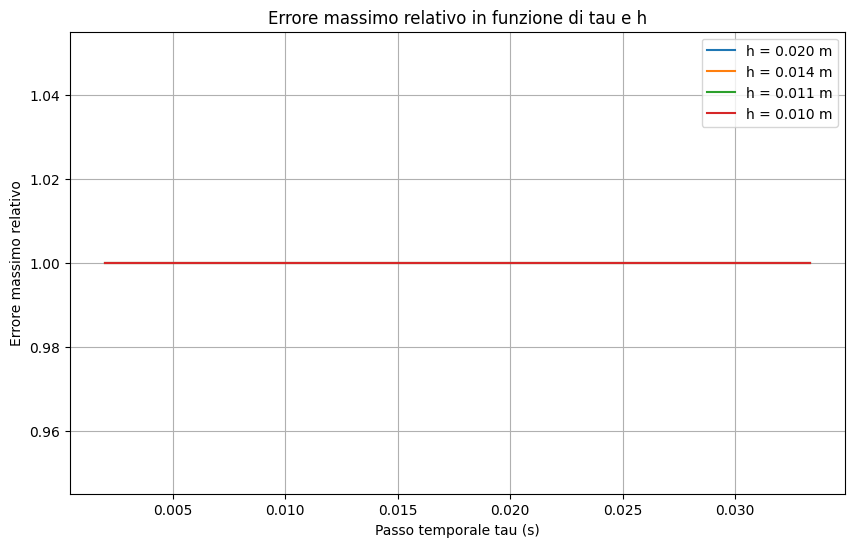

In [38]:

n_values = [50, 70, 90, 100]
m_values = [3, 6, 10, 15, 20, 50] 
errors = np.zeros((len(n_values), len(m_values)))


for i, n in enumerate(n_values):  # loop on space 
    for j, m in enumerate(m_values):   # loop in time 
        errors[i, j] = solve_heat_equation(n, m)

h_values = [L / n for n in n_values]
tau_values = [T / m for m in m_values]

plt.figure(figsize=(10, 6))
for i, h in enumerate(h_values):
    plt.plot(tau_values, errors[i, :], label=f"h = {h:.3f} m")

plt.xlabel("Passo temporale tau (s)")
plt.ylabel("Errore massimo relativo")
plt.title("Errore massimo relativo in funzione di tau e h")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
## OPTIONAL WAY FOR A MATRIX 
'''
alpha=1 

A = np.zeros((n, n))  # A == K  
for i in range(1, n-1):
    A[i, i - 1] = -alpha
    A[i, i] = 2 * alpha
    A[i, i + 1] = -alpha

# Condizioni di Neumann
A[0, 0] =   alpha
A[0, 1] = - alpha
A[-1, -1] = alpha
A[-1, -2] = -alpha

A
'''

'\nalpha=1 \n\nA = np.zeros((n, n))  # A == K  \nfor i in range(1, n-1):\n    A[i, i - 1] = -alpha\n    A[i, i] = 2 * alpha\n    A[i, i + 1] = -alpha\n\n# Condizioni di Neumann\nA[0, 0] =   alpha\nA[0, 1] = - alpha\nA[-1, -1] = alpha\nA[-1, -2] = -alpha\n\nA\n'

In [ ]:
# system con Drichlet conditions , diffusion coeff, and forzamento 

'''
import numpy as np
import matplotlib.pyplot as plt

# Parametri
alpha = 1
L = 1
T = 0.1
n = 50
m = 1000
h = L / (n - 1)
dt = T / m
x = np.linspace(0, L, n)
t = np.linspace(0, T, m)

# Condizioni iniziali
u0_fun = lambda x: 100 * np.cos(np.pi * x)
u0 = u0_fun(x)

# Costruzione della matrice J (schema implicito)
r = alpha * dt / h**2
J = np.diag((1 + 2 * r) * np.ones(n)) + np.diag(-r * np.ones(n - 1), 1) + np.diag(-r * np.ones(n - 1), -1)

# Condizioni al contorno di Dirichlet
J[0, :] = 0
J[0, 0] = 1
J[-1, :] = 0
J[-1, -1] = 1

# Termini di forzamento
f_func = lambda x: np.sin(np.pi * x)

# Ciclo temporale
u = np.zeros((m, n))
u[0, :] = u0

for j in range(m - 1):
    b = u[j, :] + dt * f_func(x)
    b[0] = 0  # Condizioni al contorno
    b[-1] = 0
    u[j + 1, :] = np.linalg.solve(J, b)

# Soluzione esatta
u_exact = lambda x, t: 100 * np.exp(-np.pi**2 * t) * np.cos(np.pi * x)

# Calcolo dell'errore
max_error = np.max(np.abs(u[-1, :] - u_exact(x, T)))
print(f"Errore massimo: {max_error}")

# Plot
plt.plot(x, u[-1, :], label="Numerica")
plt.plot(x, u_exact(x, T), '--', label="Esatta")
plt.legend()
plt.show()

'''